# 03A - Pass/Fail Risk Model

This notebook develops the **mandatory Pass/Fail Risk Model** for the Smart Learning System.

It follows the outputs generated by:

- `01_Data_Understanding_EDA.ipynb`
- `02_Data_Preprocessing.ipynb`

The model predicts whether a student is likely to pass or fail based on attendance, homework completion, midterm performance, and study hours.

## 1. Notebook Objectives

This notebook includes all steps required for the Pass/Fail model development stage:

- Load the processed Pass/Fail dataset from Notebook 02
- Validate features and target
- Check class distribution
- Split the dataset into training and testing sets
- Prevent data leakage using train-only preprocessing pipelines
- Train and compare Logistic Regression, Decision Tree, and Random Forest
- Evaluate models using accuracy, balanced accuracy, precision, recall, F1-score, confusion matrix, and cross-validation scores
- Select the best model using balanced and F1-based metrics
- Save comparison reports and figures for the project documentation

Final `.pkl` export is intentionally left for the final evaluation/export notebook after tuning.

In [1]:
from pathlib import Path
import json
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display as display_image

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

## 2. Resolve Project Paths

The notebook can be executed from the project root or from the `ml-model/notebooks` directory.

In [2]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    ML_ROOT = NOTEBOOK_DIR.parent
elif NOTEBOOK_DIR.name == "ml-model":
    ML_ROOT = NOTEBOOK_DIR
else:
    ML_ROOT = NOTEBOOK_DIR / "ml-model"

PROCESSED_DATA_DIR = ML_ROOT / "datasets" / "processed"
FIGURES_DIR = ML_ROOT / "outputs" / "figures"
REPORTS_DIR = ML_ROOT / "outputs" / "reports"
MODELS_DIR = ML_ROOT / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

PASS_FAIL_DATASET = PROCESSED_DATA_DIR / "pass_fail_processed.csv"
METADATA_PATH = PROCESSED_DATA_DIR / "preprocessing_metadata.json"

print("ML root:", ML_ROOT.resolve())
print("Processed dataset:", PASS_FAIL_DATASET.resolve())
print("Reports directory:", REPORTS_DIR.resolve())
print("Figures directory:", FIGURES_DIR.resolve())

ML root: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model
Processed dataset: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/pass_fail_processed.csv
Reports directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports
Figures directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures


## 3. Load Preprocessing Metadata

Notebook 02 exported metadata containing the final feature list and target name. This notebook uses that metadata to stay aligned with the preprocessing stage.

In [3]:
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata file not found: {METADATA_PATH.resolve()}")

metadata = json.loads(METADATA_PATH.read_text())

pass_fail_features = metadata["pass_fail_features"]
pass_fail_target = metadata["pass_fail_target"]

print("Features:", pass_fail_features)
print("Target:", pass_fail_target)
print("Target meaning:", metadata.get("pass_fail_target_meaning"))
print("Data leakage note:", metadata.get("data_leakage_prevention"))

Features: ['attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week']
Target: pass
Target meaning: {'0': 'Fail', '1': 'Pass'}
Data leakage note: Scaling, fitted imputation, encoding objects and resampling are fitted only on the training split during model training.


## 4. Data Leakage Prevention

This notebook uses scikit-learn pipelines so preprocessing steps are fitted only on the training split.

- Median imputation is fitted on training data only
- Standard scaling is fitted on training data only
- Cross-validation uses the full pipeline inside each fold
- Test data is used only for final evaluation

This prevents data leakage from the test set into training.

## 5. Load Pass/Fail Processed Dataset

The processed file was generated by Notebook 02.

In [4]:
if not PASS_FAIL_DATASET.exists():
    raise FileNotFoundError(f"Pass/Fail processed dataset not found: {PASS_FAIL_DATASET.resolve()}")

pass_fail_df = pd.read_csv(PASS_FAIL_DATASET)

print("Dataset shape:", pass_fail_df.shape)
display(pass_fail_df.head())

Dataset shape: (1500, 6)


,student_id,attendance_pct,homework_pct,commerce_average_score,study_hours_per_week,pass
0,1,59.7,66.5,73.4,6.4,1
1,2,74.3,54.7,18.3,1.2,0
2,3,81.8,98.9,70.7,11.1,1
3,4,89.4,85.3,74.2,5.6,1
4,5,60.5,21.9,37.3,7.5,0


## 6. Validate Required Columns and Data Types

The feature and target columns must match the metadata from Notebook 02.

In [ ]:
# Align feature names with the currently saved processed dataset.
feature_replacements = {
    "midterm_score": "commerce_average_score",
}

missing_columns = [column for column in pass_fail_features + [pass_fail_target] if column not in pass_fail_df.columns]
if missing_columns:
    pass_fail_features = [
        feature_replacements.get(feature, feature)
        if feature not in pass_fail_df.columns
        else feature
        for feature in pass_fail_features
    ]

required_columns = pass_fail_features + [pass_fail_target]
missing_columns = [column for column in required_columns if column not in pass_fail_df.columns]

if missing_columns:
    print("Still missing columns after feature-name alignment:", missing_columns)
    print("Falling back to numeric model features from the processed dataset.")
    pass_fail_features = [
        column for column in pass_fail_df.select_dtypes(include="number").columns
        if column not in ["student_id", pass_fail_target]
    ]
    required_columns = pass_fail_features + [pass_fail_target]
    missing_columns = [column for column in required_columns if column not in pass_fail_df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are available.")
print("Aligned features:", pass_fail_features)
display(pass_fail_df[required_columns].dtypes.to_frame("Data Type"))

## 7. Target Distribution and Class Balance

The target uses binary labels:

- `0 = Fail`
- `1 = Pass`

In [ ]:
def class_distribution(df, target):
    target_counts = df[target].value_counts(dropna=False)
    target_percentages = df[target].value_counts(normalize=True, dropna=False) * 100

    return pd.DataFrame({
        "Count": target_counts,
        "Percentage": target_percentages.round(2),
    })

pass_fail_class_summary = class_distribution(pass_fail_df, pass_fail_target)
display(pass_fail_class_summary)

class_balance_path = REPORTS_DIR / "pass_fail_class_balance_summary.csv"
pass_fail_class_summary.to_csv(class_balance_path)
print("Saved:", class_balance_path.resolve())

,Count,Percentage
pass,,
1,60,60.0
0,40,40.0


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/pass_fail_class_balance_summary.csv


## 8. Feature and Target Separation

The `student_id` column is retained for traceability in the dataset but excluded from model training.

In [ ]:
X = pass_fail_df[pass_fail_features]
y = pass_fail_df[pass_fail_target].astype(int)

print("Feature columns:", pass_fail_features)
print("Target column:", pass_fail_target)
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

Feature columns: ['attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week']
Target column: pass
X shape: (100, 4)
y shape: (100,)


,attendance_pct,homework_pct,midterm_score,study_hours_per_week
0,95,92,88,12
1,88,85,79,10
2,60,55,58,4
3,72,70,65,6
4,40,45,50,3


## 9. Train/Test Split

A stratified split is used to preserve the pass/fail class ratio in both training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame([
    {"Split": "Training", "Rows": len(X_train), "Pass Count": int((y_train == 1).sum()), "Fail Count": int((y_train == 0).sum())},
    {"Split": "Testing", "Rows": len(X_test), "Pass Count": int((y_test == 1).sum()), "Fail Count": int((y_test == 0).sum())},
])

display(split_summary)

,Split,Rows,Pass Count,Fail Count
0,Training,80,48,32
1,Testing,20,12,8


## 10. Define Candidate Models

The notebook compares three supervised learning algorithms:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Pipelines are used so preprocessing is fitted only on training data.

In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            max_depth=5,
        )),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ]),
}

list(models.keys())

['Logistic Regression', 'Decision Tree', 'Random Forest']

## 11. Train Models and Evaluate on Test Set

Metrics used:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [ ]:
def evaluate_binary_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_probability = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_probability)
    else:
        roc_auc = np.nan

    return y_pred, {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc,
    }

trained_models = {}
predictions = {}
comparison_rows = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred, metrics = evaluate_binary_model(model, X_test, y_test)

    trained_models[model_name] = model
    predictions[model_name] = y_pred
    comparison_rows.append({"Model": model_name, **metrics})

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.round(4))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,1.00,1.0000,1.0,1.0000,1.0000,1.0000
1,Decision Tree,0.95,0.9583,1.0,0.9167,0.9565,0.9583
2,Random Forest,1.00,1.0000,1.0,1.0000,1.0000,1.0000


## 12. Cross-Validation Evaluation

Cross-validation provides a more stable estimate than a single train/test split.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_rows = []

for model_name, model in models.items():
    cv_scores = cross_validate(model, X, y, cv=cv, scoring=scoring)

    cv_rows.append({
        "Model": model_name,
        "CV Accuracy": cv_scores["test_accuracy"].mean(),
        "CV Balanced Accuracy": cv_scores["test_balanced_accuracy"].mean(),
        "CV Precision": cv_scores["test_precision"].mean(),
        "CV Recall": cv_scores["test_recall"].mean(),
        "CV F1 Score": cv_scores["test_f1"].mean(),
        "CV ROC AUC": cv_scores["test_roc_auc"].mean(),
    })

cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(4))

,Model,CV Accuracy,CV Balanced Accuracy,CV Precision,CV Recall,CV F1 Score,CV ROC AUC
0,Logistic Regression,0.99,0.9917,1.0,0.9833,0.9913,1.0000
1,Decision Tree,0.99,0.9917,1.0,0.9833,0.9913,0.9917
2,Random Forest,1.00,1.0000,1.0,1.0000,1.0000,1.0000


## 13. Combined Model Comparison

The best model is selected using cross-validation F1-score first, followed by balanced accuracy and test F1-score.

In [ ]:
full_comparison_df = comparison_df.merge(cv_df, on="Model")
full_comparison_df = full_comparison_df.sort_values(
    ["CV F1 Score", "CV Balanced Accuracy", "F1 Score", "Balanced Accuracy"],
    ascending=False,
).reset_index(drop=True)

display(full_comparison_df.round(4))

comparison_path = REPORTS_DIR / "pass_fail_model_comparison.csv"
full_comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path.resolve())

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy,CV Balanced Accuracy,CV Precision,CV Recall,CV F1 Score,CV ROC AUC
0,Random Forest,1.00,1.0000,1.0,1.0000,1.0000,1.0000,1.00,1.0000,1.0,1.0000,1.0000,1.0000
1,Logistic Regression,1.00,1.0000,1.0,1.0000,1.0000,1.0000,0.99,0.9917,1.0,0.9833,0.9913,1.0000
2,Decision Tree,0.95,0.9583,1.0,0.9167,0.9565,0.9583,0.99,0.9917,1.0,0.9833,0.9913,0.9917


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/pass_fail_model_comparison.csv


## 14. Best Model Selection

The best model is selected from the sorted comparison table.

In [ ]:
best_model_name = full_comparison_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print("Best Pass/Fail model:", best_model_name)
print("Selection metrics:")
display(full_comparison_df.iloc[[0]].round(4))

Best Pass/Fail model: Random Forest
Selection metrics:


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy,CV Balanced Accuracy,CV Precision,CV Recall,CV F1 Score,CV ROC AUC
0,Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 15. Classification Report for Best Model

In [ ]:
print(classification_report(
    y_test,
    best_predictions,
    target_names=["Fail", "Pass"],
    zero_division=0,
))

best_report = classification_report(
    y_test,
    best_predictions,
    target_names=["Fail", "Pass"],
    zero_division=0,
    output_dict=True,
)

best_report_path = REPORTS_DIR / "pass_fail_best_model_classification_report.json"
best_report_path.write_text(json.dumps(best_report, indent=2))
print("Saved:", best_report_path.resolve())

              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         8
        Pass       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/pass_fail_best_model_classification_report.json


## 16. Confusion Matrix for Best Model

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/pass_fail_best_model_confusion_matrix.png


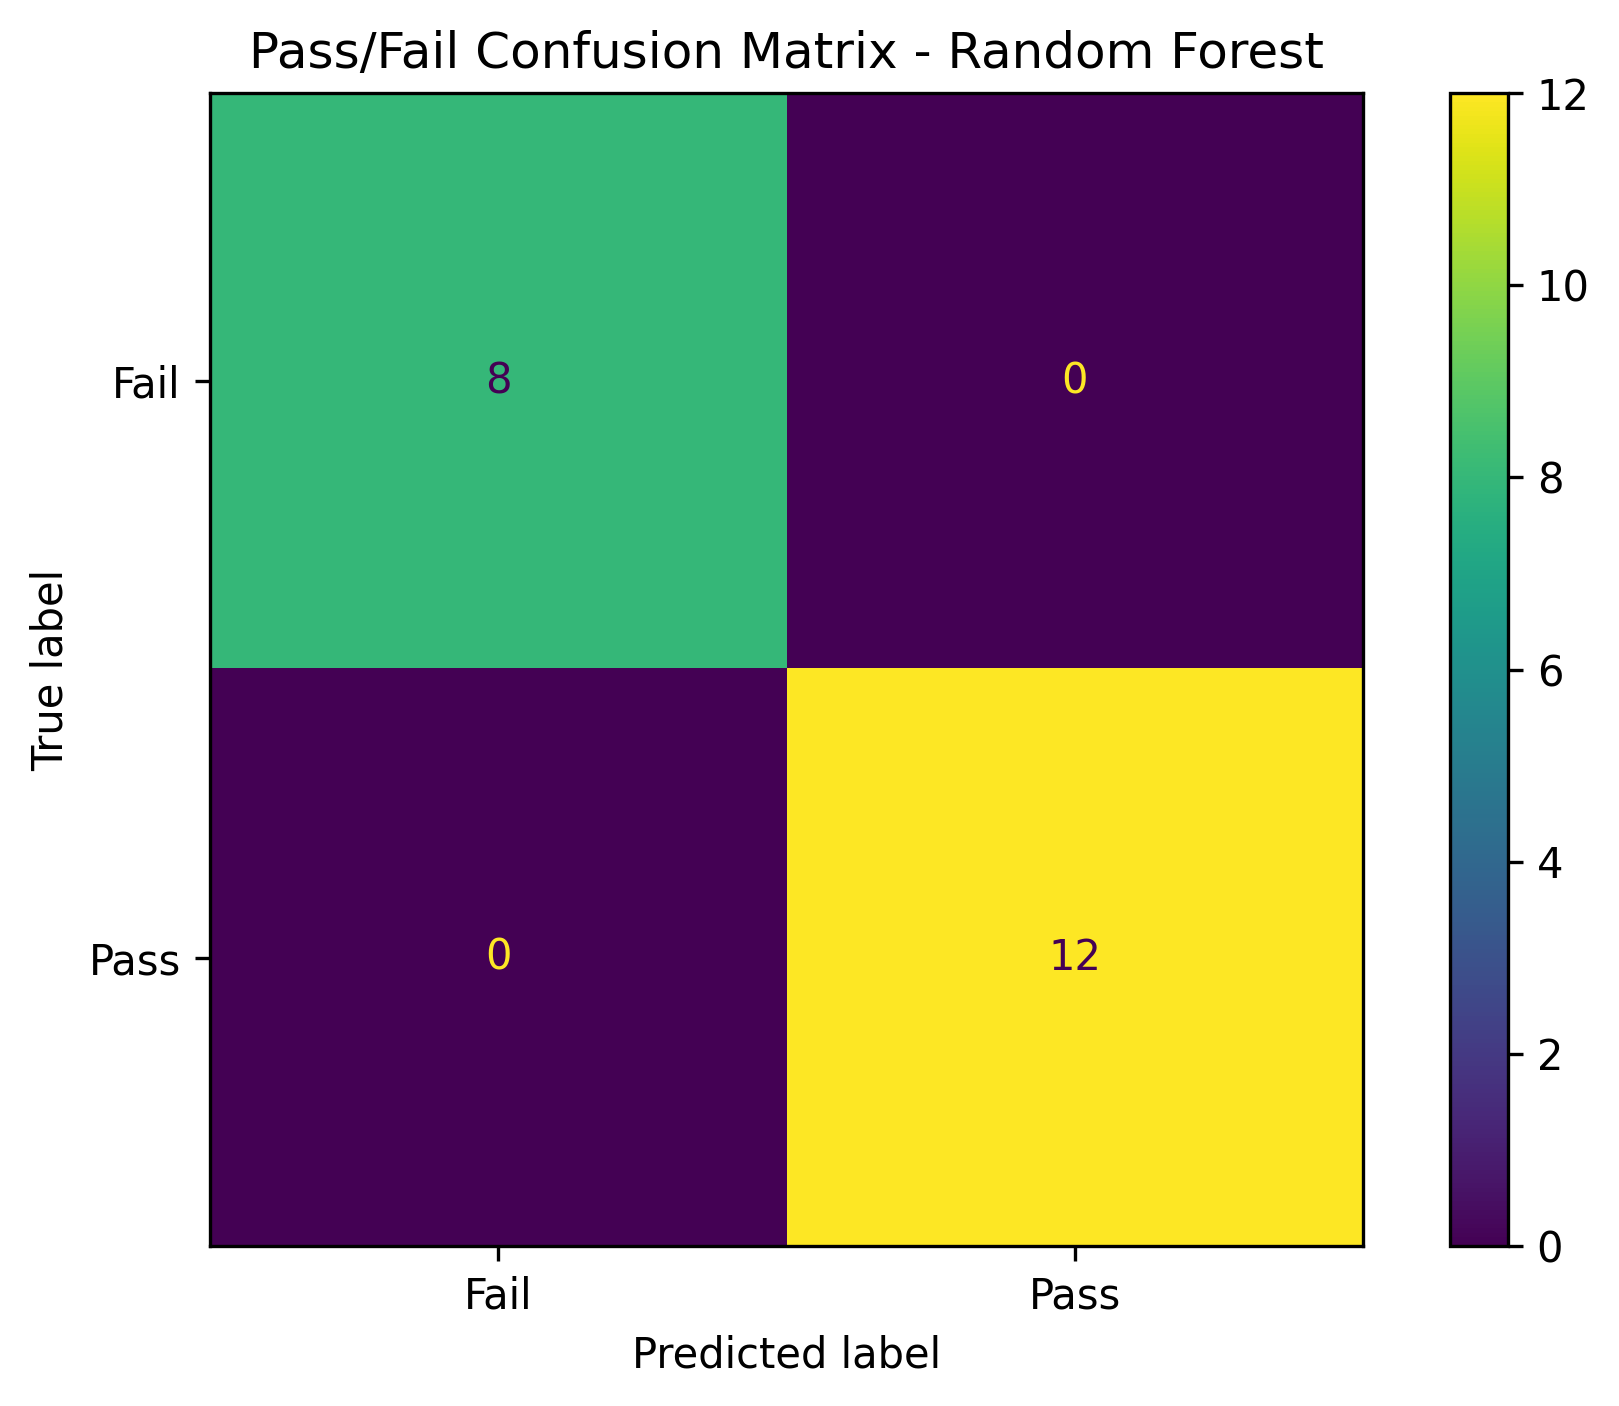

In [ ]:
matrix = confusion_matrix(y_test, best_predictions, labels=[0, 1])
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["Fail", "Pass"],
)

display_matrix.plot(values_format="d")
plt.title(f"Pass/Fail Confusion Matrix - {best_model_name}")
plt.tight_layout()

confusion_matrix_path = FIGURES_DIR / "pass_fail_best_model_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved:", confusion_matrix_path.resolve())
display_image(Image(filename=str(confusion_matrix_path)))

## 17. Confusion Matrices for All Models

This helps compare error patterns between candidate models.

In [ ]:
for model_name, y_pred in predictions.items():
    matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Fail", "Pass"],
    )

    display_matrix.plot(values_format="d")
    plt.title(f"Pass/Fail Confusion Matrix - {model_name}")
    plt.tight_layout()

    safe_name = model_name.lower().replace(" ", "_")
    output_path = FIGURES_DIR / f"pass_fail_{safe_name}_confusion_matrix.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()

    print("Saved:", output_path.resolve())
    display_image(Image(filename=str(output_path)))

## 18. Feature Importance / Coefficient Analysis

Tree-based models provide feature importance. Logistic Regression provides coefficients after scaling.

In [ ]:
importance_rows = []

for model_name, model in trained_models.items():
    final_estimator = model.named_steps["model"]

    if hasattr(final_estimator, "feature_importances_"):
        values = final_estimator.feature_importances_
        importance_type = "feature_importance"
    elif hasattr(final_estimator, "coef_"):
        values = np.abs(final_estimator.coef_[0])
        importance_type = "absolute_coefficient"
    else:
        continue

    for feature, value in zip(pass_fail_features, values):
        importance_rows.append({
            "Model": model_name,
            "Importance Type": importance_type,
            "Feature": feature,
            "Value": value,
        })

importance_df = pd.DataFrame(importance_rows).sort_values(
    ["Model", "Value"],
    ascending=[True, False],
)

display(importance_df.round(4))

importance_path = REPORTS_DIR / "pass_fail_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)
print("Saved:", importance_path.resolve())

,Model,Importance Type,Feature,Value
4,Decision Tree,feature_importance,attendance_pct,1.0000
5,Decision Tree,feature_importance,homework_pct,0.0000
6,Decision Tree,feature_importance,midterm_score,0.0000
7,Decision Tree,feature_importance,study_hours_per_week,0.0000
0,Logistic Regression,absolute_coefficient,attendance_pct,1.4637
1,Logistic Regression,absolute_coefficient,homework_pct,1.4250
3,Logistic Regression,absolute_coefficient,study_hours_per_week,1.3200
2,Logistic Regression,absolute_coefficient,midterm_score,1.2558
9,Random Forest,feature_importance,homework_pct,0.3250
8,Random Forest,feature_importance,attendance_pct,0.3050


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/pass_fail_feature_importance.csv


## 19. Best Model Summary for Documentation

In [ ]:
best_model_summary = {
    "task": "Pass/Fail Risk Prediction",
    "dataset": str(PASS_FAIL_DATASET),
    "features": pass_fail_features,
    "target": pass_fail_target,
    "target_meaning": {"0": "Fail", "1": "Pass"},
    "candidate_models": list(models.keys()),
    "best_model": best_model_name,
    "selection_criteria": [
        "CV F1 Score",
        "CV Balanced Accuracy",
        "Test F1 Score",
        "Test Balanced Accuracy",
    ],
    "random_state": RANDOM_STATE,
    "data_leakage_prevention": "Imputation and scaling are fitted only inside train-only pipelines.",
}

summary_path = REPORTS_DIR / "pass_fail_best_model_summary.json"
summary_path.write_text(json.dumps(best_model_summary, indent=2))

print("Saved:", summary_path.resolve())
best_model_summary

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/pass_fail_best_model_summary.json


{'task': 'Pass/Fail Risk Prediction',
 'dataset': '/Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/pass_fail_processed.csv',
 'features': ['attendance_pct',
  'homework_pct',
  'midterm_score',
  'study_hours_per_week'],
 'target': 'pass',
 'target_meaning': {'0': 'Fail', '1': 'Pass'},
 'candidate_models': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
 'best_model': 'Random Forest',
 'selection_criteria': ['CV F1 Score',
  'CV Balanced Accuracy',
  'Test F1 Score',
  'Test Balanced Accuracy'],
 'random_state': 42,
 'data_leakage_prevention': 'Imputation and scaling are fitted only inside train-only pipelines.'}

## 21. Notebook Conclusion

This notebook developed the mandatory Pass/Fail Risk Model for the Smart Learning System. The processed dataset from Notebook 02 was loaded, validated and split into training and testing sets. Logistic Regression, Decision Tree and Random Forest models were trained using leakage-safe pipelines.

The models were compared using accuracy, balanced accuracy, precision, recall, F1-score, ROC-AUC and cross-validation metrics. The best model was selected using cross-validation F1-score and balanced accuracy rather than accuracy alone.

The generated reports and figures can be used in the project report and in later notebooks for tuning, final evaluation and model export.